In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np
from pyts.classification import TimeSeriesForest

from tqdm.notebook import tqdm

from typing import Literal

%matplotlib inline

In [5]:
def full_filename_from_path(path):
    g = path.split('.')[0]
    return f'Data/genres_original/{g}/{path}'


def get_sb(audio_path):
    n_fft = 2048
    hop_length = 512
    audio_path = full_filename_from_path(audio_path)
    y, sr = librosa.load(audio_path, sr=None)
    sb = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft,
                                            hop_length=hop_length)
    return sb.flatten()


def get_zero_crossing_rate(audio_path):
    frame_length = 2048
    hop_length = 512
    audio_path = full_filename_from_path(audio_path)
    y, _ = librosa.load(audio_path, sr=None)
    zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=frame_length,
                                             hop_length=hop_length)
    return zcr.flatten()


def get_rms(audio_path):
    frame_length = 2048
    hop_length = 512
    audio_path = full_filename_from_path(audio_path)
    y, _ = librosa.load(audio_path, sr=None)
    rms = librosa.feature.rms(y=y, frame_length=frame_length,
                              hop_length=hop_length)
    return rms.flatten()


def downsample(x, factor=5):
    return x[::factor]


feature_to_function = {
        "rms": get_rms,
        "zero_crossing_rate": get_zero_crossing_rate,
        "spectral_bandwidth": get_sb,
}

In [ ]:
'''
1 - zbudować dataframe z szeregiem czasowym (na rezie tylko z jednej wartości)
2 - użyć time series forest do klasyfikacji
'''
def create_timeseries_dataframe(
    csv_path: str,
    feature: Literal["rms", "zero_crossing_rate", "spectral_bandwidth"] = "rms",
    downsample_factor: int = 5,
    verbose: bool = False
) -> pd.DataFrame:

    get_fun = feature_to_function[feature]
    df = pd.read_csv(csv_path)

    df = df[df['filename'] != 'jazz.00054.wav'].reset_index(drop=True)

    records = []

    if verbose:
        print("Computing time series...")

    for _, row in tqdm(df.iterrows(), total=len(df)):
        path = row['filename']
        label = row['label']

        ts = get_fun(path)
        ts = downsample(ts, factor=downsample_factor)

        records.append({
            "filename": path,
            "ts": ts,
            "label": label
        })

    ts_df = pd.DataFrame(records)
    return ts_df

In [44]:
ts_df = create_timeseries_dataframe("Data/features_30_sec.csv", feature="rms", downsample_factor=10, verbose=True)

max_length = max(len(ts) for ts in ts_df['ts'])

X = pd.DataFrame(
    np.array([np.pad(ts, (0, max_length - len(ts))) for ts in ts_df['ts']]),
    columns=[f'ts_{i}' for i in range(max_length)]
)
y = np.array(ts_df['label'].tolist())

Computing time series...


  0%|          | 0/999 [00:00<?, ?it/s]

# Baseline TimeSeriesForest

In [31]:
from model_evaluation import EvalConfig, EvalModel
from sklearn.pipeline import Pipeline
import numpy as np

pipeline = Pipeline([
    ('TSF', TimeSeriesForest(n_estimators=100, random_state=42))
])

config = EvalConfig(
    train_path="Data/features_30_sec.csv",
    X=X,
    y=y,
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

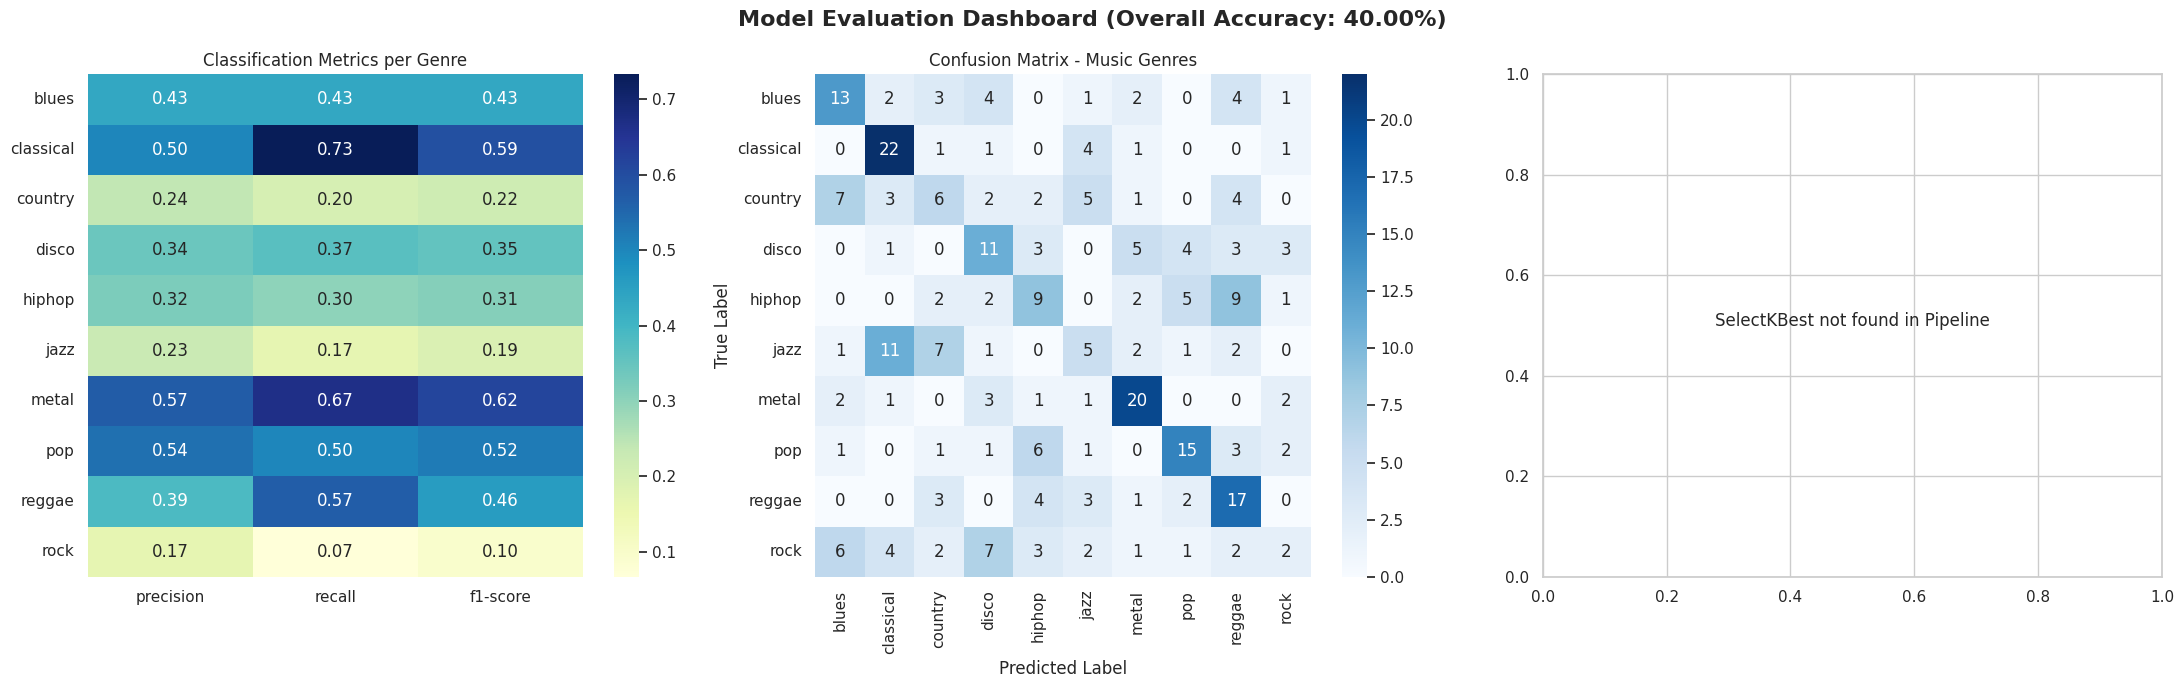

In [32]:
evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()

# Ensemble of a normal model and TSF

1.  wytrenowac RF i TSF
2. zrobic ensemble

In [36]:
from sklearn.preprocessing import StandardScaler

class EnsembleModel:
	def __init__(self, model, ts_model, w=0.5):
		self.pipeline = Pipeline([
			("scaler", StandardScaler()),
			('clf', model),
		]) 
		self.ts_model = ts_model
		self.w = w

	def fit(self, X, y):
		ts_columns = [col for col in X.columns if col.startswith('ts_')]
		ts_X = X[ts_columns]
		X = X.drop(columns=ts_columns)
		self.pipeline.fit(X, y)
		self.ts_model.fit(ts_X, y)

	def predict_proba(self, X):
		ts_columns = [col for col in X.columns if col.startswith('ts_')]
		ts_X = X[ts_columns]
		X = X.drop(columns=ts_columns)
		proba1 = self.pipeline.predict_proba(X)
		proba2 = self.ts_model.predict_proba(ts_X)
		return (self.w * proba1 + (1 - self.w) * proba2) / 2
	
	def predict(self, X):
		proba = self.predict_proba(X)
		return np.argmax(proba, axis=1)

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

clf = EnsembleModel(
  model=RandomForestClassifier(n_estimators=100, random_state=42),
  ts_model=TimeSeriesForest(n_estimators=100, random_state=42),
  w=0.95,
)

df = pd.read_csv("Data/features_30_sec.csv")
df = pd.concat([df, X], axis=1)

le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['filename', 'length', 'label']), y_encoded, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

y_pred_genres = le.inverse_transform(y_pred)
y_test_genres = le.inverse_transform(y_test)

accuracy = accuracy_score(y_test_genres, y_pred_genres)
print(f"Ensemble Model Accuracy: {accuracy:.4f}")

Ensemble Model Accuracy: 0.7900
